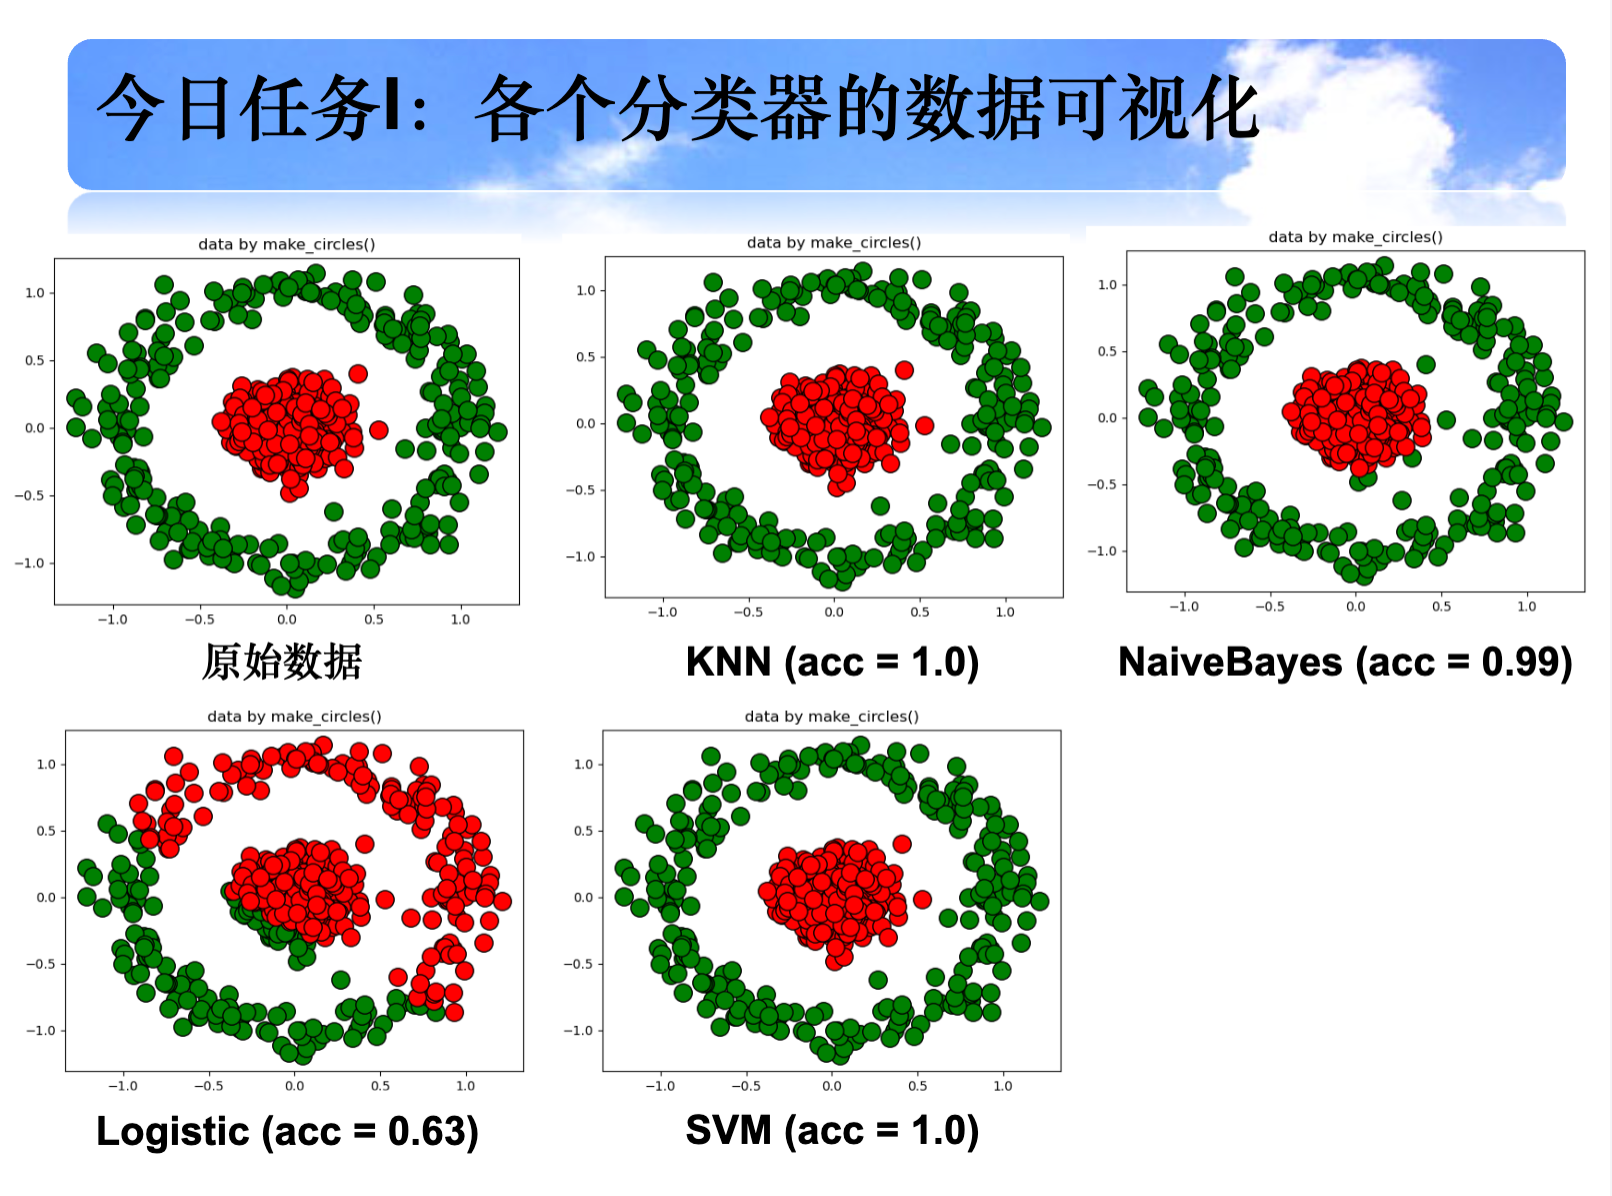

# 任务一

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [2]:
X, y = make_circles(
    n_samples=500,
    noise=0.1,
    factor=0.3,
    random_state=42
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("类别:", np.unique(y))

X shape: (500, 2)
y shape: (500,)
类别: [0 1]


原始数据

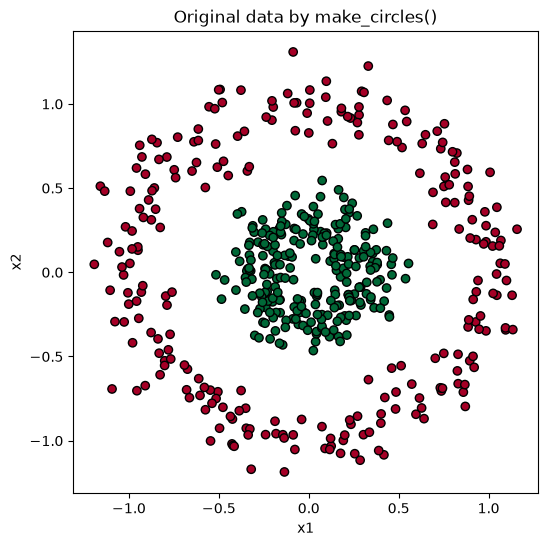

In [3]:
plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="RdYlGn",
    edgecolors="black"
)

plt.title("Original data by make_circles()")
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

划分训练集

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("训练集:", X_train.shape, y_train.shape)
print("测试集:", X_test.shape, y_test.shape)

训练集: (350, 2) (350,)
测试集: (150, 2) (150,)


评分

In [5]:
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)

print("KNN accuracy =", acc_knn)

KNN accuracy = 1.0


KNN可视化

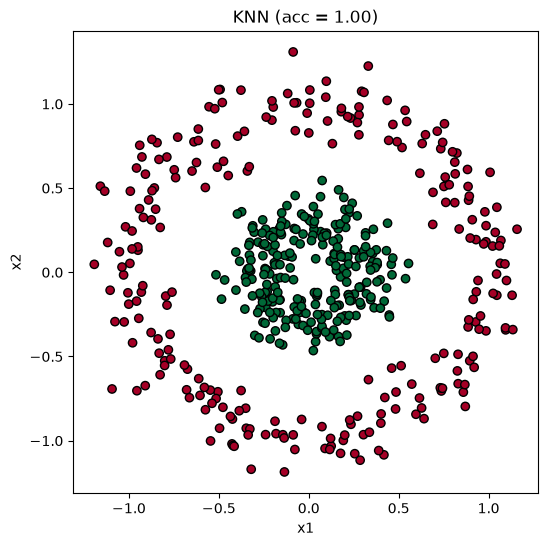

In [6]:
y_all_knn = knn.predict(X)

plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_all_knn,
    cmap="RdYlGn",
    edgecolors="black"
)

plt.title(f"KNN (acc = {acc_knn:.2f})")
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

Naive Bayes

In [7]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes accuracy =", acc_nb)

Naive Bayes accuracy = 0.98


作图

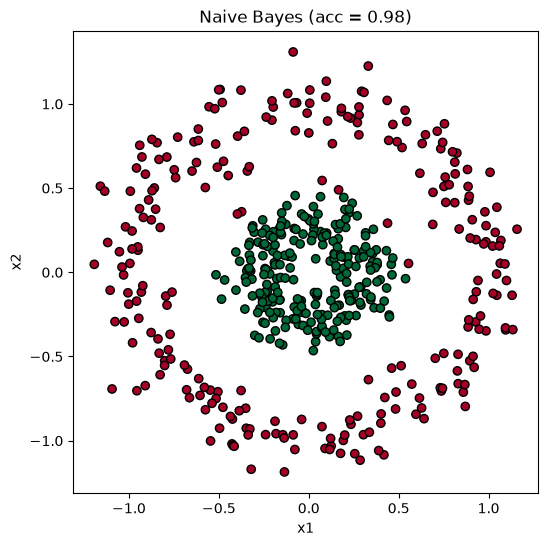

In [8]:
y_all_nb = nb.predict(X)

plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_all_nb,
    cmap="RdYlGn",
    edgecolors="black"
)

plt.title(f"Naive Bayes (acc = {acc_nb:.2f})")
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

Logistic Regression

In [9]:
logistic = LogisticRegression()

logistic.fit(X_train, y_train)

y_pred_logistic = logistic.predict(X_test)

acc_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression accuracy =", acc_logistic)

Logistic Regression accuracy = 0.47333333333333333


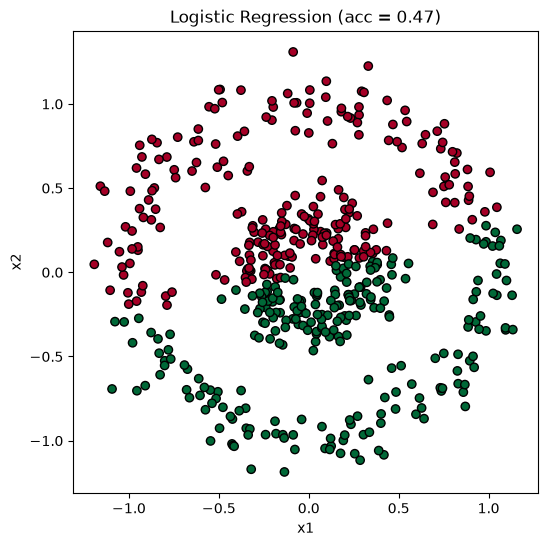

In [10]:
y_all_logistic = logistic.predict(X)

plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_all_logistic,
    cmap="RdYlGn",
    edgecolors="black"
)

plt.title(f"Logistic Regression (acc = {acc_logistic:.2f})")
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

SVM

In [11]:
svm = SVC(kernel="rbf")

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)

print("SVM accuracy =", acc_svm)

SVM accuracy = 1.0


SVM作图

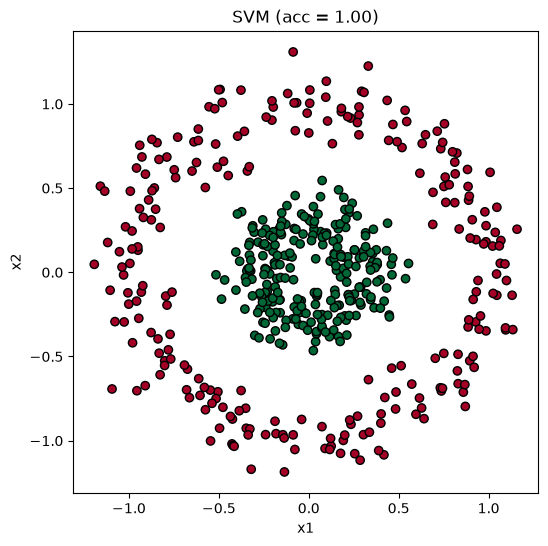

In [12]:
y_all_svm = svm.predict(X)

plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y_all_svm,
    cmap="RdYlGn",
    edgecolors="black"
)

plt.title(f"SVM (acc = {acc_svm:.2f})")
plt.xlabel("x1")
plt.ylabel("x2")

plt.show()

最终比较

In [13]:
print("KNN                 =", acc_knn)
print("Naive Bayes         =", acc_nb)
print("Logistic Regression =", acc_logistic)
print("SVM                 =", acc_svm)

KNN                 = 1.0
Naive Bayes         = 0.98
Logistic Regression = 0.47333333333333333
SVM                 = 1.0


五图总输出

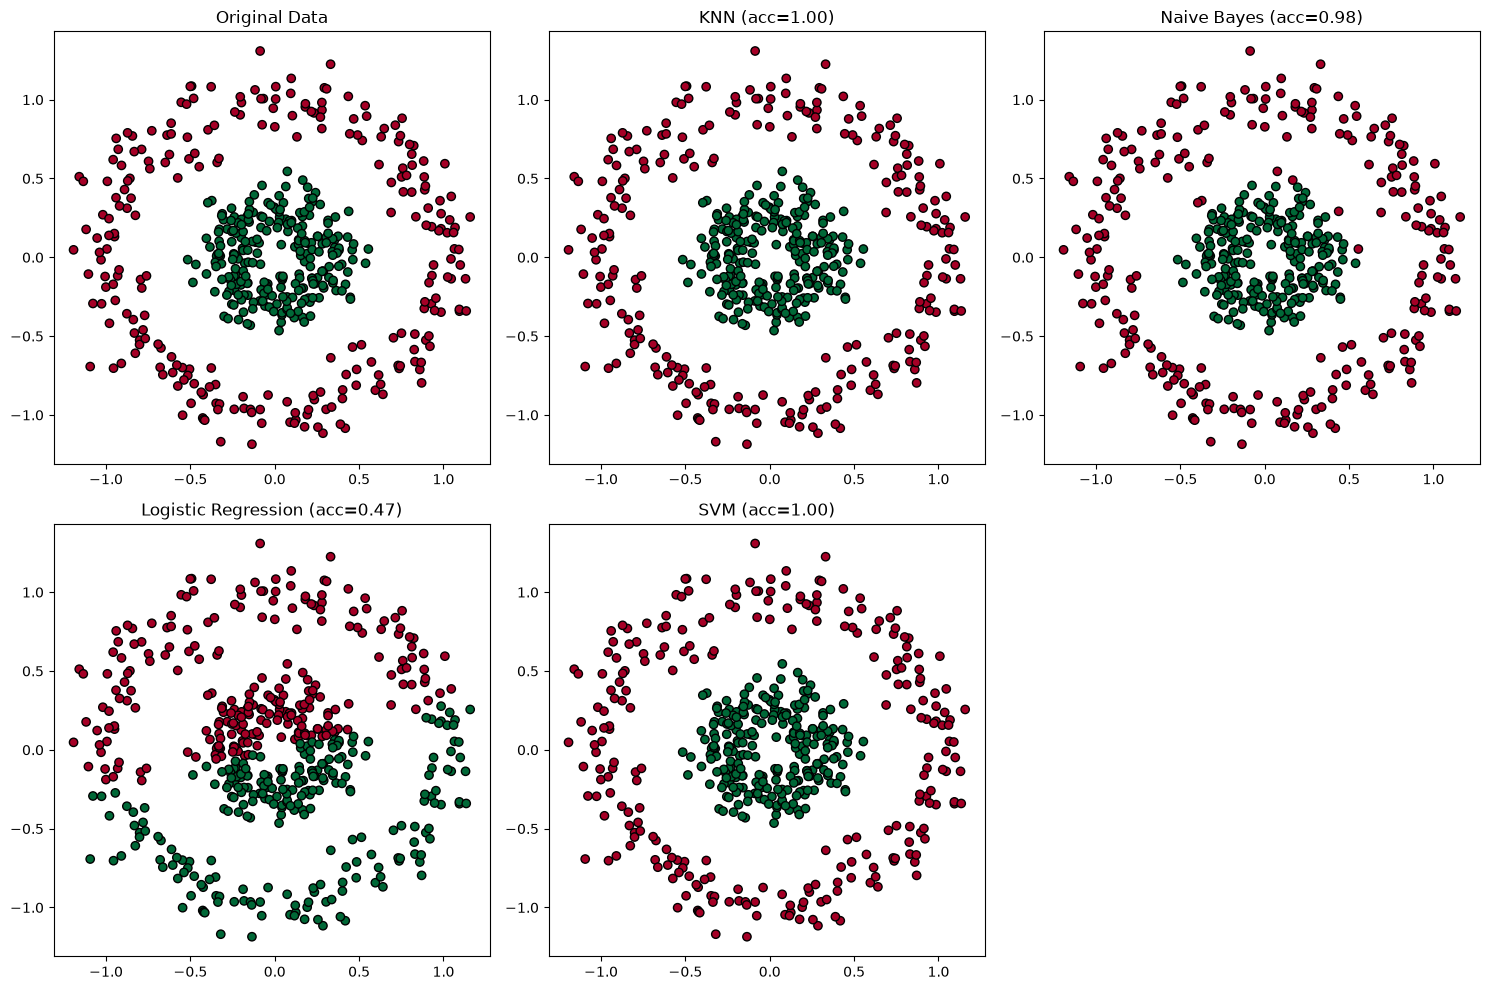

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. 原始数据
axes[0, 0].scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="RdYlGn",
    edgecolors="black"
)
axes[0, 0].set_title("Original Data")

# 2. KNN
axes[0, 1].scatter(
    X[:, 0],
    X[:, 1],
    c=y_all_knn,
    cmap="RdYlGn",
    edgecolors="black"
)
axes[0, 1].set_title(f"KNN (acc={acc_knn:.2f})")

# 3. Naive Bayes
axes[0, 2].scatter(
    X[:, 0],
    X[:, 1],
    c=y_all_nb,
    cmap="RdYlGn",
    edgecolors="black"
)
axes[0, 2].set_title(f"Naive Bayes (acc={acc_nb:.2f})")

# 4. Logistic Regression
axes[1, 0].scatter(
    X[:, 0],
    X[:, 1],
    c=y_all_logistic,
    cmap="RdYlGn",
    edgecolors="black"
)
axes[1, 0].set_title(
    f"Logistic Regression (acc={acc_logistic:.2f})"
)

# 5. SVM
axes[1, 1].scatter(
    X[:, 0],
    X[:, 1],
    c=y_all_svm,
    cmap="RdYlGn",
    edgecolors="black"
)
axes[1, 1].set_title(f"SVM (acc={acc_svm:.2f})")

# 第 6 个位置不用
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

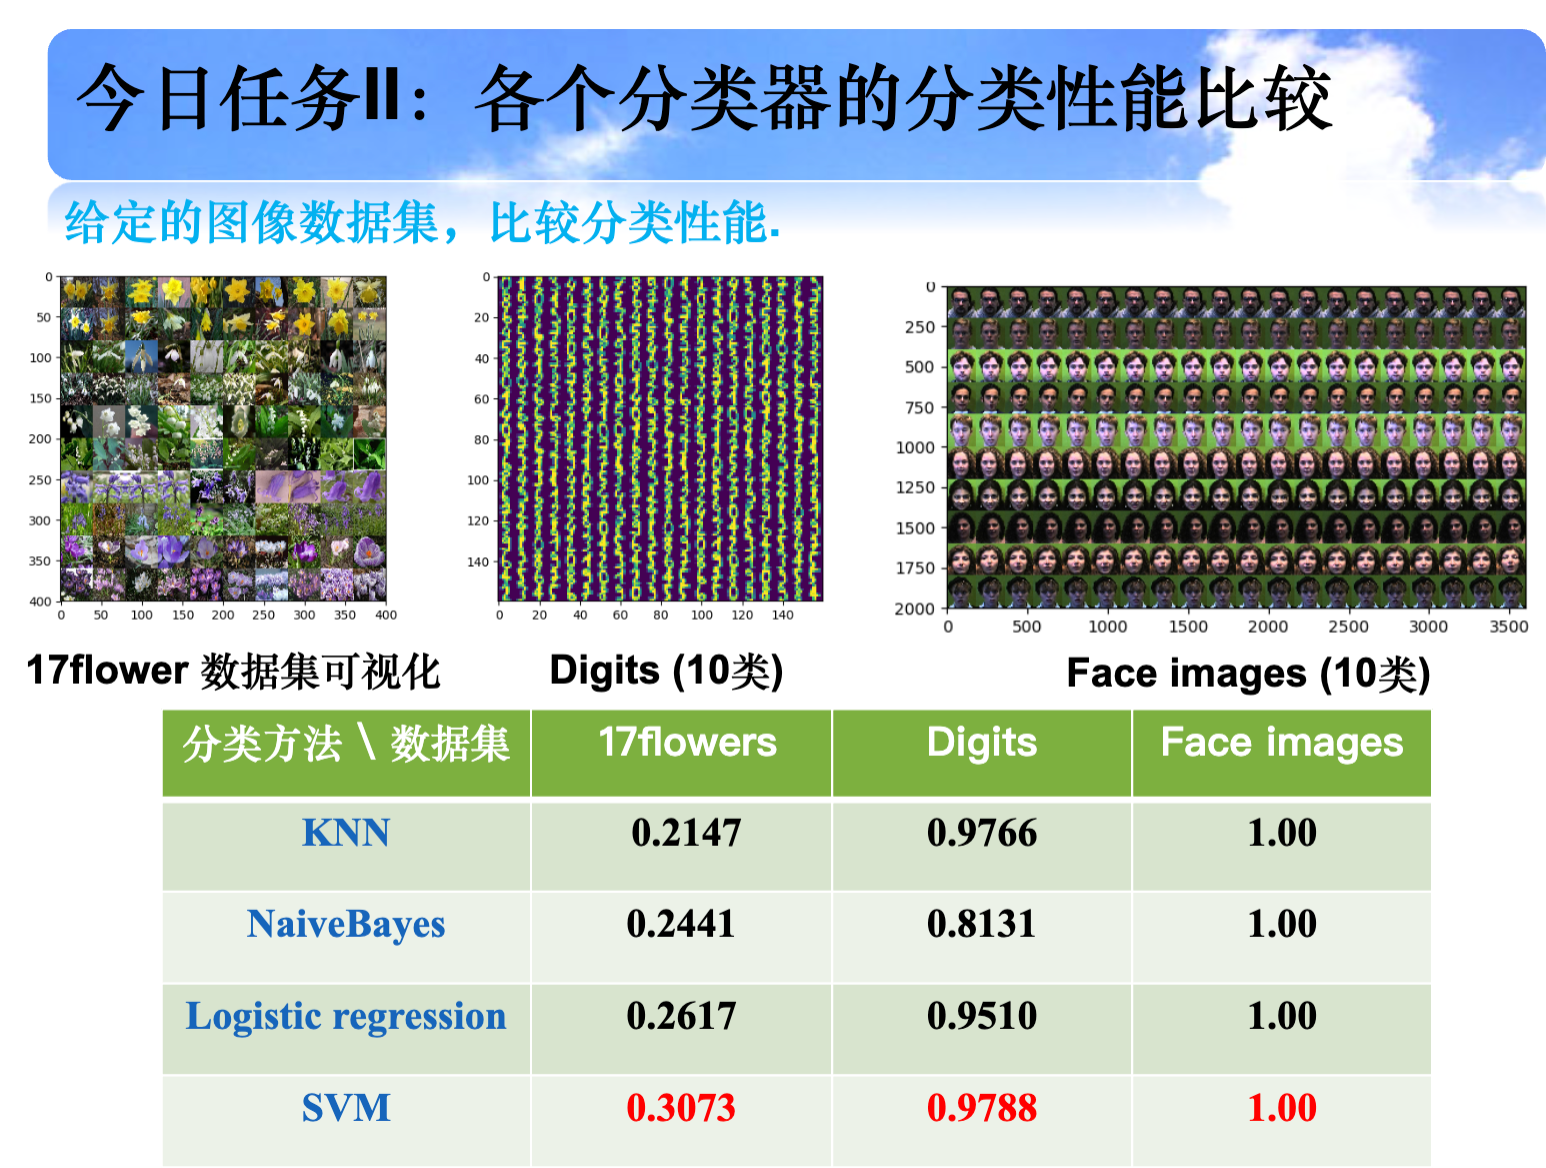

# 任务二

## digit

In [15]:
from sklearn.datasets import load_digits

digits = load_digits()

X_digits = digits.data
y_digits = digits.target

print("数据形状:", X_digits.shape)
print("标签形状:", y_digits.shape)
print("类别:", np.unique(y_digits))

数据形状: (1797, 64)
标签形状: (1797,)
类别: [0 1 2 3 4 5 6 7 8 9]


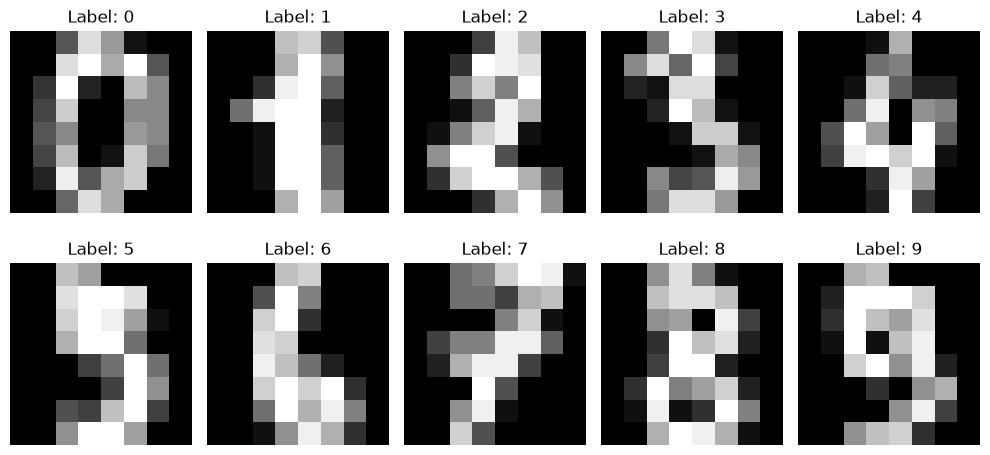

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(
        digits.images[i],
        cmap="gray"
    )
    ax.set_title(f"Label: {y_digits[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

划分训练集和数据集

In [17]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits,
    y_digits,
    test_size=0.3,
    random_state=42,
    stratify=y_digits
)

print("训练集:", X_train_d.shape)
print("测试集:", X_test_d.shape)

训练集: (1257, 64)
测试集: (540, 64)


KNN

In [18]:
knn_digits = KNeighborsClassifier(n_neighbors=3)

knn_digits.fit(X_train_d, y_train_d)

y_pred = knn_digits.predict(X_test_d)

acc_knn_digits = accuracy_score(y_test_d, y_pred)

print("Digits - KNN accuracy =", acc_knn_digits)

Digits - KNN accuracy = 0.987037037037037


Naive Bayes

In [19]:
nb_digits = GaussianNB()

nb_digits.fit(X_train_d, y_train_d)

y_pred_nb_d = nb_digits.predict(X_test_d)

acc_nb_digits = accuracy_score(y_test_d, y_pred_nb_d)

print("Digits - Naive Bayes accuracy =", acc_nb_digits)

Digits - Naive Bayes accuracy = 0.8222222222222222


Logistic Regression

In [20]:
logistic_digits = LogisticRegression(
    max_iter=2000
)

logistic_digits.fit(X_train_d, y_train_d)

y_pred_logistic_d = logistic_digits.predict(X_test_d)

acc_logistic_digits = accuracy_score(
    y_test_d,
    y_pred_logistic_d
)

print(
    "Digits - Logistic Regression accuracy =",
    acc_logistic_digits
)

Digits - Logistic Regression accuracy = 0.9574074074074074


SVM

In [21]:
svm_digits = SVC(
    kernel="rbf"
)

svm_digits.fit(X_train_d, y_train_d)

y_pred_svm_d = svm_digits.predict(X_test_d)

acc_svm_digits = accuracy_score(
    y_test_d,
    y_pred_svm_d
)

print("Digits - SVM accuracy =", acc_svm_digits)

Digits - SVM accuracy = 0.9888888888888889


合并结果

In [22]:
print("Digits 分类结果")
print("------------------------------")
print(f"KNN                 : {acc_knn_digits:.4f}")
print(f"Naive Bayes         : {acc_nb_digits:.4f}")
print(f"Logistic Regression : {acc_logistic_digits:.4f}")
print(f"SVM                 : {acc_svm_digits:.4f}")

Digits 分类结果
------------------------------
KNN                 : 0.9870
Naive Bayes         : 0.8222
Logistic Regression : 0.9574
SVM                 : 0.9889


## Face images

In [23]:
import os
from PIL import Image
face_dir = "../dataset/face_images"

X_face = []
y_face = []

classes = sorted(os.listdir(face_dir))

for label, class_name in enumerate(classes):
    class_path = os.path.join(face_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):
        file_path = os.path.join(class_path, file_name)

        try:
            img = Image.open(file_path).convert("L")
            img = np.array(img)

            X_face.append(img.flatten())
            y_face.append(label)

        except:
            pass

X_face = np.array(X_face)
y_face = np.array(y_face)

print("Face data shape:", X_face.shape)
print("Face label shape:", y_face.shape)
print("类别数:", len(np.unique(y_face)))

Face data shape: (200, 36000)
Face label shape: (200,)
类别数: 10


PCA

In [24]:
from sklearn.decomposition import PCA

pca_face = PCA(
    n_components=0.95,
    random_state=42
)

X_face_pca = pca_face.fit_transform(X_face)

print("原始维度:", X_face.shape)
print("PCA 后维度:", X_face_pca.shape)
print(
    "累计解释率:",
    pca_face.explained_variance_ratio_.sum()
)

原始维度: (200, 36000)
PCA 后维度: (200, 13)
累计解释率: 0.9524206127242345


划分训练集

In [25]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_face_pca,
    y_face,
    test_size=0.3,
    random_state=42,
    stratify=y_face
)

print("训练集:", X_train_f.shape)
print("测试集:", X_test_f.shape)

训练集: (140, 13)
测试集: (60, 13)


KNN

In [26]:
knn_face = KNeighborsClassifier(n_neighbors=3)

knn_face.fit(X_train_f, y_train_f)

y_pred_knn_f = knn_face.predict(X_test_f)

acc_knn_face = accuracy_score(
    y_test_f,
    y_pred_knn_f
)

print("Face - KNN accuracy =", acc_knn_face)

Face - KNN accuracy = 1.0


Naive Bayes

In [27]:
nb_face = GaussianNB()

nb_face.fit(X_train_f, y_train_f)

y_pred_nb_f = nb_face.predict(X_test_f)

acc_nb_face = accuracy_score(
    y_test_f,
    y_pred_nb_f
)

print("Face - Naive Bayes accuracy =", acc_nb_face)

Face - Naive Bayes accuracy = 1.0


Logistic Regression

In [28]:
logistic_face = LogisticRegression(
    max_iter=2000
)

logistic_face.fit(X_train_f, y_train_f)

y_pred_logistic_f = logistic_face.predict(X_test_f)

acc_logistic_face = accuracy_score(
    y_test_f,
    y_pred_logistic_f
)

print(
    "Face - Logistic Regression accuracy =",
    acc_logistic_face
)

Face - Logistic Regression accuracy = 1.0


SVM

In [29]:
svm_face = SVC(
    kernel="rbf"
)

svm_face.fit(X_train_f, y_train_f)

y_pred_svm_f = svm_face.predict(X_test_f)

acc_svm_face = accuracy_score(
    y_test_f,
    y_pred_svm_f
)

print("Face - SVM accuracy =", acc_svm_face)

Face - SVM accuracy = 1.0


比较

In [30]:
print("Face Images 分类结果")
print("------------------------------")
print(f"KNN                 : {acc_knn_face:.4f}")
print(f"Naive Bayes         : {acc_nb_face:.4f}")
print(f"Logistic Regression : {acc_logistic_face:.4f}")
print(f"SVM                 : {acc_svm_face:.4f}")

Face Images 分类结果
------------------------------
KNN                 : 1.0000
Naive Bayes         : 1.0000
Logistic Regression : 1.0000
SVM                 : 1.0000


## 17flowers

In [31]:
import os
from PIL import Image

flower_dir = "../dataset/17flowers"

X_flower = []
y_flower = []

files = sorted([
    f for f in os.listdir(flower_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print("找到图片数量:", len(files))


找到图片数量: 1360


In [32]:
for i, file_name in enumerate(files):

    file_path = os.path.join(flower_dir, file_name)

    img = Image.open(file_path).convert("RGB")

    # 所有图片统一成 64×64
    img = img.resize((64, 64))

    img = np.array(img)

    # 64 × 64 × 3 → 一维向量
    X_flower.append(img.flatten())

    # 17flowers 每类 80 张
    label = i // 80
    y_flower.append(label)

X_flower = np.array(X_flower)
y_flower = np.array(y_flower)

print("Flower data shape:", X_flower.shape)
print("Flower label shape:", y_flower.shape)

print("类别:", np.unique(y_flower))
print("类别数:", len(np.unique(y_flower)))

Flower data shape: (1360, 12288)
Flower label shape: (1360,)
类别: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
类别数: 17


PCA

In [33]:
from sklearn.decomposition import PCA

pca_flower = PCA(
    n_components=0.95,
    random_state=42
)

X_flower_pca = pca_flower.fit_transform(X_flower)

print("原始维度:", X_flower.shape)
print("PCA 后维度:", X_flower_pca.shape)
print(
    "累计解释率:",
    pca_flower.explained_variance_ratio_.sum()
)

原始维度: (1360, 12288)
PCA 后维度: (1360, 529)
累计解释率: 0.9501536447419847


划分训练集

In [34]:
X_train_fl, X_test_fl, y_train_fl, y_test_fl = train_test_split(
    X_flower_pca,
    y_flower,
    test_size=0.3,
    random_state=42,
    stratify=y_flower
)

print("训练集:", X_train_fl.shape)
print("测试集:", X_test_fl.shape)

训练集: (952, 529)
测试集: (408, 529)


四个分类器

In [35]:
# KNN
knn_flower = KNeighborsClassifier(n_neighbors=3)
knn_flower.fit(X_train_fl, y_train_fl)

y_pred_knn_fl = knn_flower.predict(X_test_fl)

acc_knn_flower = accuracy_score(
    y_test_fl,
    y_pred_knn_fl
)


# Naive Bayes
nb_flower = GaussianNB()
nb_flower.fit(X_train_fl, y_train_fl)

y_pred_nb_fl = nb_flower.predict(X_test_fl)

acc_nb_flower = accuracy_score(
    y_test_fl,
    y_pred_nb_fl
)


# Logistic Regression
logistic_flower = LogisticRegression(
    max_iter=3000
)

logistic_flower.fit(X_train_fl, y_train_fl)

y_pred_logistic_fl = logistic_flower.predict(X_test_fl)

acc_logistic_flower = accuracy_score(
    y_test_fl,
    y_pred_logistic_fl
)


# SVM
svm_flower = SVC(kernel="rbf")

svm_flower.fit(X_train_fl, y_train_fl)

y_pred_svm_fl = svm_flower.predict(X_test_fl)

acc_svm_flower = accuracy_score(
    y_test_fl,
    y_pred_svm_fl
)

最后汇总

In [36]:
print("17flowers 分类结果")
print("------------------------------")
print(f"KNN                 : {acc_knn_flower:.4f}")
print(f"Naive Bayes         : {acc_nb_flower:.4f}")
print(f"Logistic Regression : {acc_logistic_flower:.4f}")
print(f"SVM                 : {acc_svm_flower:.4f}")

17flowers 分类结果
------------------------------
KNN                 : 0.3113
Naive Bayes         : 0.2574
Logistic Regression : 0.4436
SVM                 : 0.5098


In [37]:
digits_results = {
    "KNN": acc_knn_digits,
    "Naive Bayes": acc_nb_digits,
    "Logistic Regression": acc_logistic_digits,
    "SVM": acc_svm_digits
}

face_results = {
    "KNN": acc_knn_face,
    "Naive Bayes": acc_nb_face,
    "Logistic Regression": acc_logistic_face,
    "SVM": acc_svm_face
}

flower_results = {
    "KNN": acc_knn_flower,
    "Naive Bayes": acc_nb_flower,
    "Logistic Regression": acc_logistic_flower,
    "SVM": acc_svm_flower
}

总比较表

In [38]:
import pandas as pd

results_df = pd.DataFrame({
    "17flowers": [
        flower_results["KNN"],
        flower_results["Naive Bayes"],
        flower_results["Logistic Regression"],
        flower_results["SVM"]
    ],
    
    "Digits": [
        digits_results["KNN"],
        digits_results["Naive Bayes"],
        digits_results["Logistic Regression"],
        digits_results["SVM"]
    ],
    
    "Face images": [
        face_results["KNN"],
        face_results["Naive Bayes"],
        face_results["Logistic Regression"],
        face_results["SVM"]
    ]
}, index=[
    "KNN",
    "NaiveBayes",
    "Logistic regression",
    "SVM"
])

results_df

,17flowers,Digits,Face images
KNN,0.311275,0.987037,1.0
NaiveBayes,0.257353,0.822222,1.0
Logistic regression,0.443627,0.957407,1.0
SVM,0.509804,0.988889,1.0


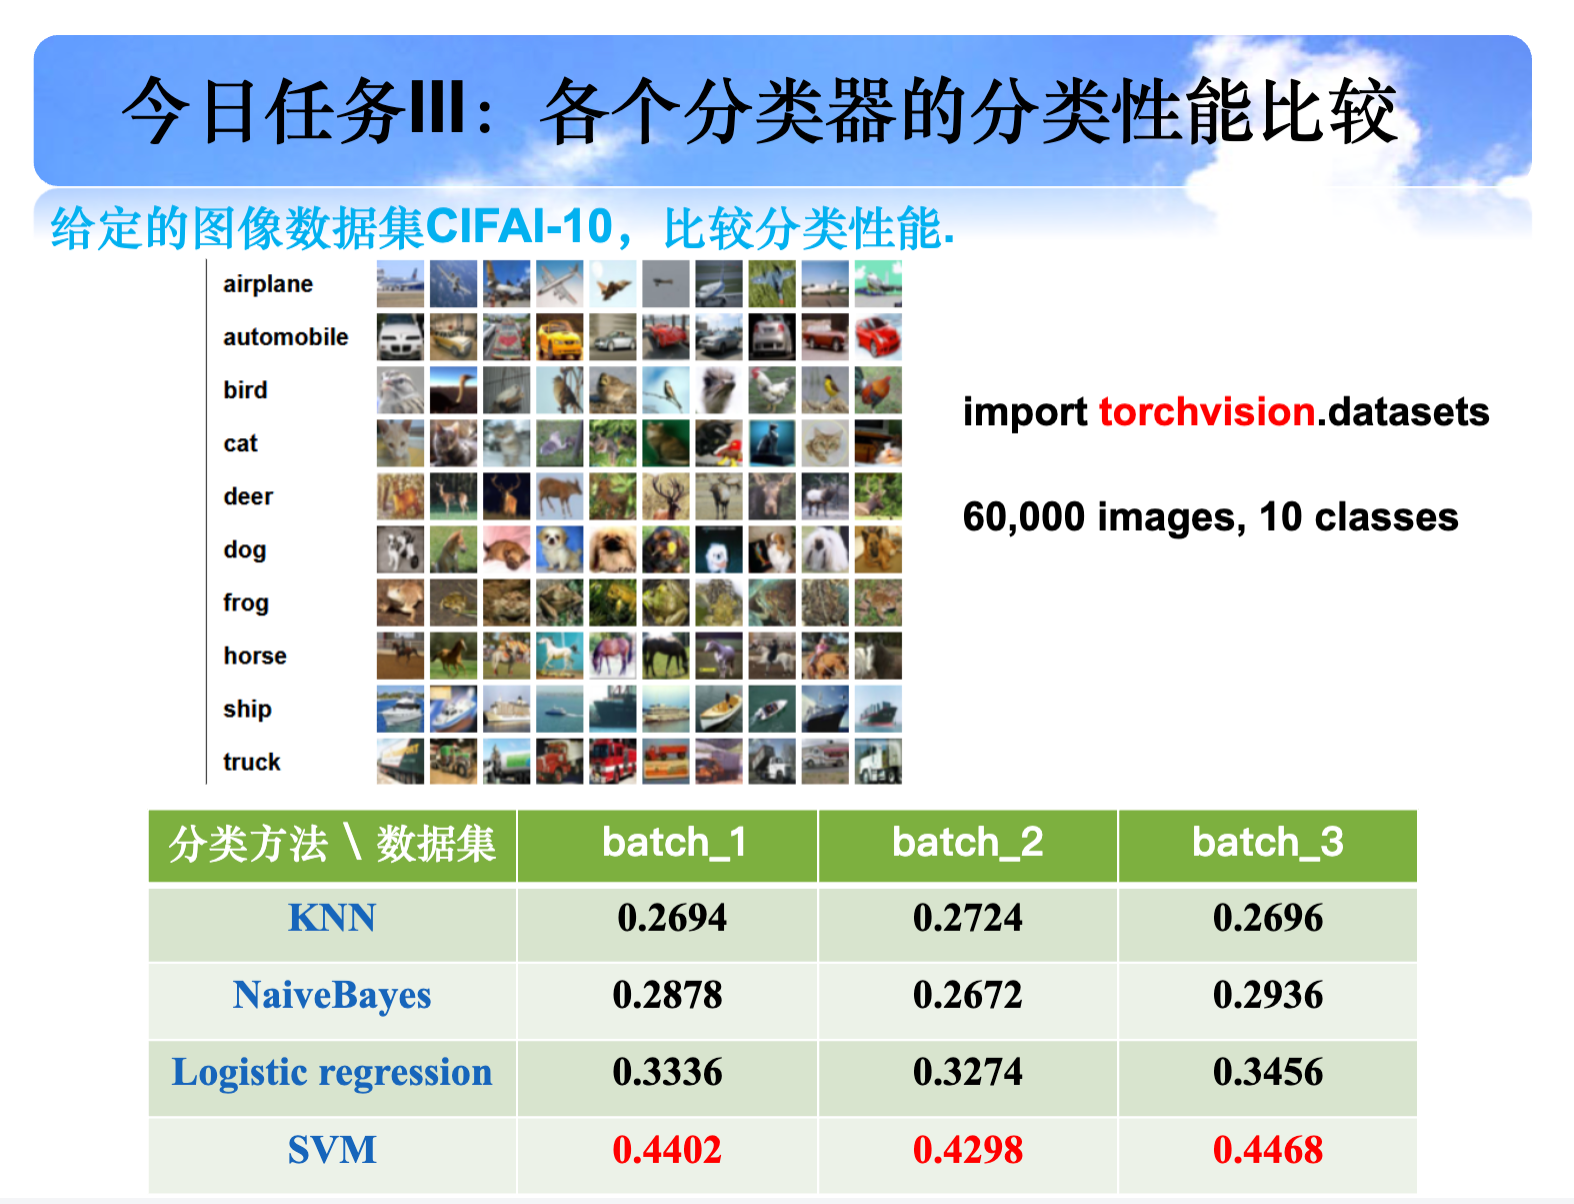

# 任务三

导入数据

In [39]:
import numpy as np
import torchvision
import torchvision.transforms as transforms

transform = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(
    root="../dataset",
    train=True,
    download=True,
    transform=transform
)


testset = torchvision.datasets.CIFAR10(
    root="../dataset",
    train=False,
    download=True,
    transform=transform
)

print(trainset.data.shape)
print(len(trainset.targets))

print("训练集数量:", len(trainset))
print("测试集数量:", len(testset))
print("类别:", trainset.classes)

Files already downloaded and verified
Files already downloaded and verified
(50000, 32, 32, 3)
50000
训练集数量: 50000
测试集数量: 10000
类别: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


batch_1

In [40]:
X_batch1 = trainset.data[:10000]
y_batch1 = np.array(trainset.targets[:10000])

print(X_batch1.shape)
print(y_batch1.shape)

(10000, 32, 32, 3)
(10000,)


展平

In [41]:
X_batch1 = X_batch1.reshape(10000, -1)

print(X_batch1.shape)

(10000, 3072)


划分训练集

In [42]:
from sklearn.model_selection import train_test_split

X_train_c1, X_test_c1, y_train_c1, y_test_c1 = train_test_split(
    X_batch1,
    y_batch1,
    test_size=0.3,
    random_state=42,
    stratify=y_batch1
)

print("训练集:", X_train_c1.shape)
print("测试集:", X_test_c1.shape)

训练集: (7000, 3072)
测试集: (3000, 3072)


KNN

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn_c1 = KNeighborsClassifier(n_neighbors=3)

knn_c1.fit(X_train_c1, y_train_c1)

y_pred_knn_c1 = knn_c1.predict(X_test_c1)

acc_knn_c1 = accuracy_score(
    y_test_c1,
    y_pred_knn_c1
)

print("CIFAR-10 batch_1 KNN accuracy =", acc_knn_c1)

CIFAR-10 batch_1 KNN accuracy = 0.2786666666666667


Naive Bayes

In [44]:
from sklearn.naive_bayes import GaussianNB

nb_c1 = GaussianNB()

nb_c1.fit(X_train_c1, y_train_c1)

y_pred_nb_c1 = nb_c1.predict(X_test_c1)

acc_nb_c1 = accuracy_score(
    y_test_c1,
    y_pred_nb_c1
)

print("CIFAR-10 batch_1 Naive Bayes accuracy =", acc_nb_c1)

CIFAR-10 batch_1 Naive Bayes accuracy = 0.29333333333333333


Logistic Regression

In [45]:
X_train_c1_scaled = X_train_c1 / 255.0
X_test_c1_scaled = X_test_c1 / 255.0

from sklearn.linear_model import LogisticRegression

logistic_c1 = LogisticRegression(
    max_iter=1000
)

logistic_c1.fit(
    X_train_c1_scaled,
    y_train_c1
)

y_pred_logistic_c1 = logistic_c1.predict(
    X_test_c1_scaled
)

acc_logistic_c1 = accuracy_score(
    y_test_c1,
    y_pred_logistic_c1
)

print(
    "CIFAR-10 batch_1 Logistic Regression accuracy =",
    acc_logistic_c1
)

KeyboardInterrupt: 

SVM

In [ ]:
from sklearn.svm import SVC

svm_c1 = SVC(
    kernel="rbf"
)

svm_c1.fit(
    X_train_c1_scaled,
    y_train_c1
)

y_pred_svm_c1 = svm_c1.predict(
    X_test_c1_scaled
)

acc_svm_c1 = accuracy_score(
    y_test_c1,
    y_pred_svm_c1
)

print(
    "CIFAR-10 batch_1 SVM accuracy =",
    acc_svm_c1
)

CIFAR-10 batch_1 SVM accuracy = 0.4573333333333333


汇总batch_1

In [ ]:
print("CIFAR-10 batch_1 分类结果")
print("--------------------------------")
print(f"KNN                 : {acc_knn_c1:.4f}")
print(f"Naive Bayes         : {acc_nb_c1:.4f}")
print(f"Logistic Regression : {acc_logistic_c1:.4f}")
print(f"SVM                 : {acc_svm_c1:.4f}")

CIFAR-10 batch_1 分类结果
--------------------------------
KNN                 : 0.2787
Naive Bayes         : 0.2933
Logistic Regression : 0.3217
SVM                 : 0.4573


In [ ]:
batch1_results = {
    "KNN": acc_knn_c1,
    "Naive Bayes": acc_nb_c1,
    "Logistic Regression": acc_logistic_c1,
    "SVM": acc_svm_c1
}

优化，直接写成函数

In [ ]:
def evaluate_cifar_batch(X_batch, y_batch, batch_name):
    X_train, X_test, y_train, y_test = train_test_split(
        X_batch,
        y_batch,
        test_size=0.3,
        random_state=42,
        stratify=y_batch
    )

    # 缩放
    X_train_scaled = X_train / 255.0
    X_test_scaled = X_test / 255.0

    results = {}

    # KNN
    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    results["KNN"] = accuracy_score(y_test, pred)

    # Naive Bayes
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    pred = nb.predict(X_test)
    results["Naive Bayes"] = accuracy_score(y_test, pred)

    # Logistic Regression
    logistic = LogisticRegression(max_iter=1000)
    logistic.fit(X_train_scaled, y_train)
    pred = logistic.predict(X_test_scaled)
    results["Logistic Regression"] = accuracy_score(y_test, pred)

    # SVM
    svm = SVC(kernel="rbf")
    svm.fit(X_train_scaled, y_train)
    pred = svm.predict(X_test_scaled)
    results["SVM"] = accuracy_score(y_test, pred)

    print(f"\n{batch_name} 结果")
    print("------------------------------")

    for model, acc in results.items():
        print(f"{model:20s}: {acc:.4f}")

    return results

准备batch_1 batch_2

In [ ]:
# batch_2：第 10000 ~ 19999 张
X_batch2 = trainset.data[10000:20000].reshape(10000, -1)
y_batch2 = np.array(trainset.targets[10000:20000])

# batch_3：第 20000 ~ 29999 张
X_batch3 = trainset.data[20000:30000].reshape(10000, -1)
y_batch3 = np.array(trainset.targets[20000:30000])

print("batch_2:", X_batch2.shape, y_batch2.shape)
print("batch_3:", X_batch3.shape, y_batch3.shape)

batch_2: (10000, 3072) (10000,)
batch_3: (10000, 3072) (10000,)


运行

In [ ]:
batch2_results = evaluate_cifar_batch(
    X_batch2,
    y_batch2,
    "batch_2"
)
batch3_results = evaluate_cifar_batch(
    X_batch3,
    y_batch3,
    "batch_3"
)

/Users/caijingxi/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



batch_2 结果
------------------------------
KNN                 : 0.2633
Naive Bayes         : 0.2937
Logistic Regression : 0.3173
SVM                 : 0.4500


/Users/caijingxi/miniforge3/envs/ml/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



batch_3 结果
------------------------------
KNN                 : 0.2690
Naive Bayes         : 0.2917
Logistic Regression : 0.3367
SVM                 : 0.4660


最终汇整

In [ ]:
cifar_results = pd.DataFrame({
    "batch_1": [
        batch1_results["KNN"],
        batch1_results["Naive Bayes"],
        batch1_results["Logistic Regression"],
        batch1_results["SVM"]
    ],

    "batch_2": [
        batch2_results["KNN"],
        batch2_results["Naive Bayes"],
        batch2_results["Logistic Regression"],
        batch2_results["SVM"]
    ],

    "batch_3": [
        batch3_results["KNN"],
        batch3_results["Naive Bayes"],
        batch3_results["Logistic Regression"],
        batch3_results["SVM"]
    ]
}, index=[
    "KNN",
    "NaiveBayes",
    "Logistic regression",
    "SVM"
])

cifar_results.round(4)

,batch_1,batch_2,batch_3
KNN,0.2787,0.2633,0.2690
NaiveBayes,0.2933,0.2937,0.2917
Logistic regression,0.3217,0.3173,0.3367
SVM,0.4573,0.4500,0.4660
